<div style="border: 2px solid #ffff; border-radius: 10px; padding: 5px; width: auto; text-align: center; font-weight: bold; color: rgba(245, 8, 16, 0.96); font-size: 40px"> E-Commerce Order Profit Prediction</div>

<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px">Business Problem:</div> 
<div style="border: 2px solid #ffff; border-radius: 5px;padding: 5px; width: auto; font-size: 16px">
Many retail and e-commerce companies generate high sales but still suffer low profits due to excessive discounts, poor category performance, logistics costs, and regional inefficiencies.

For example:
- High sales does not always mean high profit
- Heavy discounts can create losses
- Some product categories perform poorly
- Certain regions generate lower margins

So businesses need a system that predicts profit before finalizing an order.

<b>Business Objective:</b>

The main objectives of this project were:
1. Predict expected profit for each order
2. Detect risk of negative profit or loss
3. Understand factors affecting profit
4. Improve discount strategy
5. Help management make better decisions
6. Build a deployable web application
</div>

<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px">1. Import Libraries </div>

In [70]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, recall_score, precision_score, f1_score, classification_report

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE


# Warnings
import warnings
warnings.filterwarnings('ignore')

# Pickle
import pickle

print("=== All Important Libraries are Imported Sucessfully! ===")

=== All Important Libraries are Imported Sucessfully! ===


<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px">2. Load the Dataset </div>

In [39]:
df = pd.read_csv("Superstore.csv", encoding='utf-8', encoding_errors='ignore')

<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px"> 3: Data Preprocessing </div>

In [40]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [41]:
# Shape of dataset
print('Total No. of Rows: ',df.shape[0])
print('Total No. of Features :',df.shape[1])

Total No. of Rows:  9994
Total No. of Features : 21


In [42]:
# Check Data Types for Each Feature
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [88]:
# Statistical Summary
df[['Sales','Quantity','Discount','Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,140.281105,3.789574,0.156203,16.068014
std,168.804241,2.225110,0.206452,29.486488
min,0.444000,1.000000,0.000000,-39.724125
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,498.930000,14.000000,0.800000,70.816875


In [44]:
# Check missing values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [45]:
# Check duplicate rows
print('Count of Duplicates: ',df.duplicated().sum())

Count of Duplicates:  0


<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px"> Data Trasformation </div>

In [46]:
# ===============================
# Convert Data types
# ===============================

cols = ['Sales','Discount','Profit']
df[cols] = df[cols].astype('float64')

In [47]:
# ===============================
# Convert Dates
# ===============================

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])


<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px"> Exploratory Data Analysis </div>

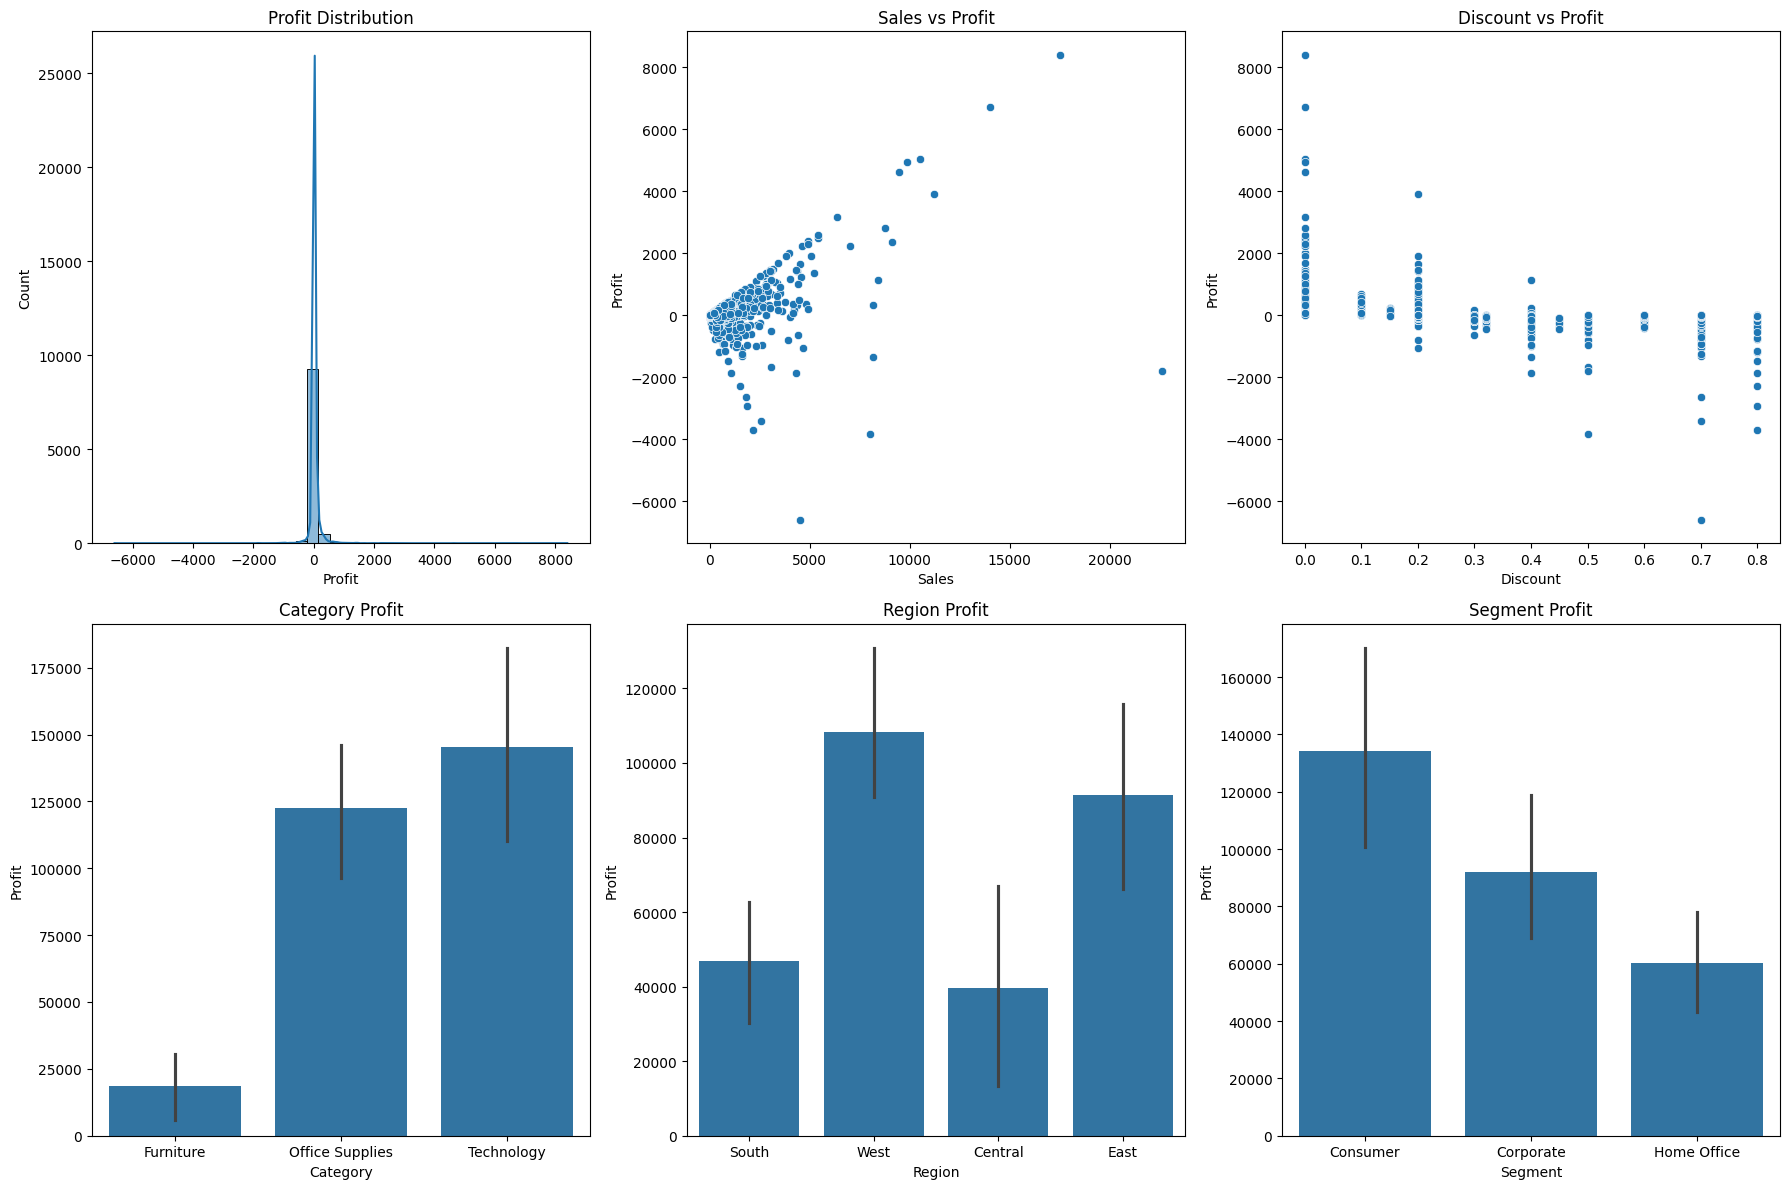

In [48]:
plt.figure(figsize=(18,12))

# ===============================
# 1 Profit Distribution
# ===============================
plt.subplot(2,3,1)
sns.histplot(df['Profit'], kde=True, bins=40)
plt.title("Profit Distribution")

# ===============================
# 2 Sales vs Profit
# ===============================
plt.subplot(2,3,2)
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit")

# ===============================
# 3 Discount vs Profit
# ===============================
plt.subplot(2,3,3)
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")

# ===============================
# 4 Category-wise Profit
# ===============================
plt.subplot(2,3,4)
sns.barplot(x='Category', y='Profit', data=df, estimator=sum)
plt.title("Category Profit")

# ===============================
# 5 Region-wise Profit
# ===============================
plt.subplot(2,3,5)
sns.barplot(x='Region', y='Profit', data=df, estimator=sum)
plt.title("Region Profit")

# ===============================
# 6 Segment-wise Profit
# ===============================
plt.subplot(2,3,6)
sns.barplot(x='Segment', y='Profit', data=df, estimator=sum)
plt.title("Segment Profit")

plt.tight_layout()
plt.show()

<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-size: 20px"> <b>Insights:</b> 
<font-size: 16px>

1. Slightly skewed distribution, Some negative profit orders & Most profits near moderate values
2. Higher sales often increase profit, but not always.
3. As discount increases, profit decreases.
4. Technology highest profit.
5. West region highest profit.
6. Different customer segments have different profitability.

</div>

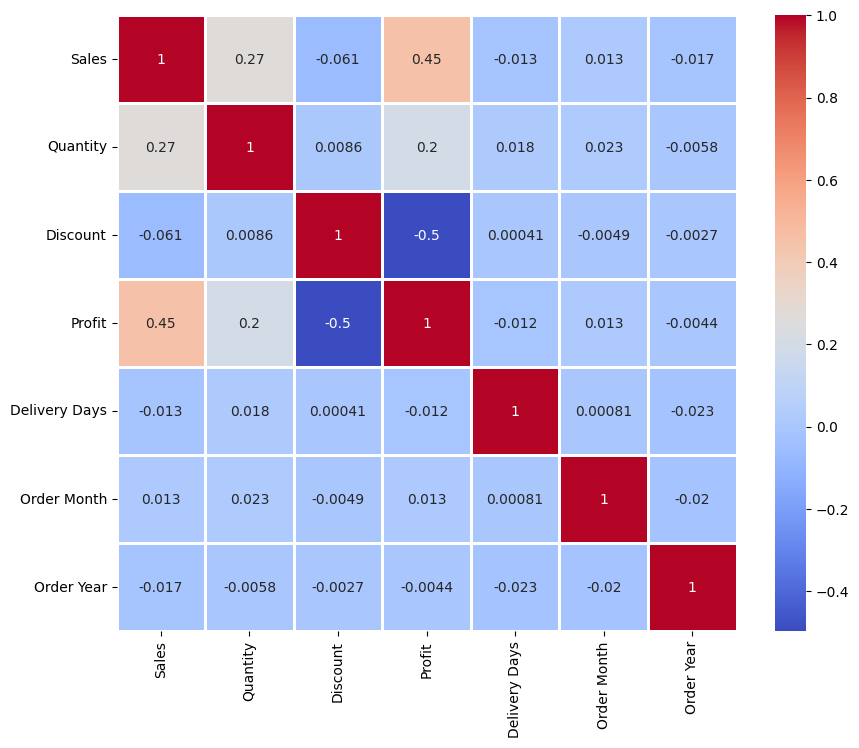

In [86]:
plt.figure(figsize=(10,8))
sns.heatmap(data=df.corr(numeric_only=(True)),annot=True, cmap='coolwarm',linewidths=2)
plt.show()

<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-size: 20px"> <b>Insights:</b> 
<font-size: 16px>

1. Strong Positive Correlations
- Sales ↔ Profit = 0.45
→ Higher sales generally lead to higher profit.

- Sales ↔ Quantity = 0.27
→ More quantity sold tends to increase sales.

- Quantity ↔ Profit = 0.20
→ Selling more items slightly increases profit.

2. Negative Correlations
- Discount ↔ Profit = -0.50 (Strongest negative relation)
→ Higher discounts reduce profit significantly.

- Sales ↔ Discount = -0.061
→ Very weak negative relation.

</div>

In [50]:
profit_orders = df[df['Profit'] > 0]
print("Total Profit Orders:", len(profit_orders))

Total Profit Orders: 8058


In [51]:
loss_orders = df[df['Profit'] < 0]
print("Total Loss Orders:", len(loss_orders))

Total Loss Orders: 1871


In [52]:
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

In [53]:
df.groupby('Discount')['Profit'].mean()

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px"> Feature Engineering </div>

In [54]:
# ===============================
# Feature Engineering
# ===============================

# Delivery Days
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Order Month
df['Order Month'] = df['Order Date'].dt.month

# Order Year
df['Order Year'] = df['Order Date'].dt.year

# Preview
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Delivery Days,Order Month,Order Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,11,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,11,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,6,2016
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,10,2015
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,10,2015


In [55]:
# Dropping Unecessary Columns
drop_cols = [
    'Row ID',
    'Order ID',
    'Customer ID',
    'Customer Name',
    'Product ID',
    'Product Name',
    'Order Date',
    'Ship Date',
    'Postal Code',
    'Country',
    'City',
    'State'
]

df = df.drop(columns=drop_cols)

df.head()

,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Delivery Days,Order Month,Order Year
0,Second Class,Consumer,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,3,11,2016
1,Second Class,Consumer,South,Furniture,Chairs,731.9400,3,0.00,219.5820,3,11,2016
2,Second Class,Corporate,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,4,6,2016
3,Standard Class,Consumer,South,Furniture,Tables,957.5775,5,0.45,-383.0310,7,10,2015
4,Standard Class,Consumer,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,7,10,2015


<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px"> Handling Outliers </div>

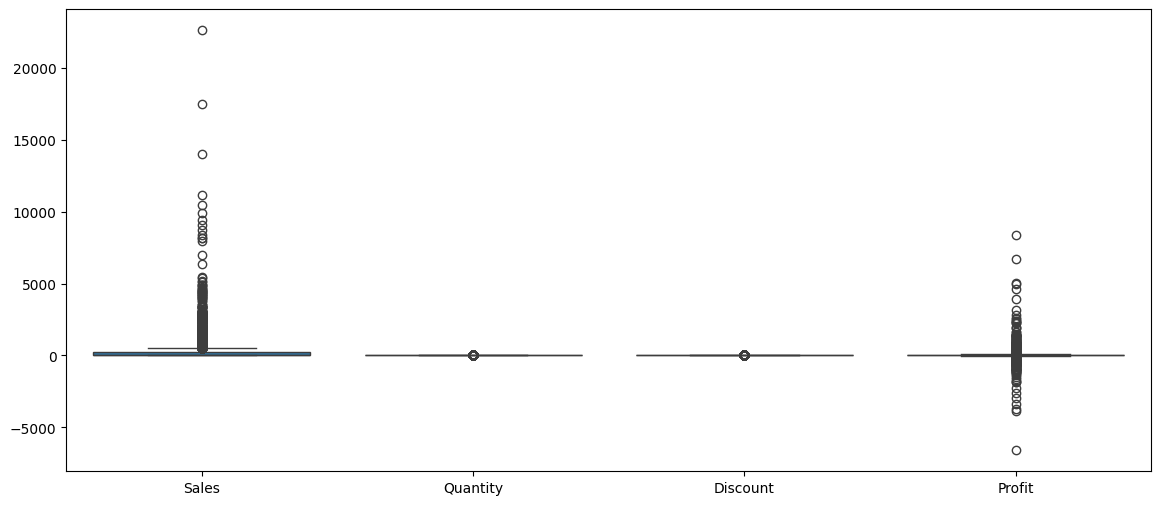

In [56]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df[['Sales','Quantity','Discount','Profit']])
plt.show()

In [57]:
# Handling Outliers with Capping Technique
def cap_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

# Apply
cap_outliers('Sales')
cap_outliers('Profit')

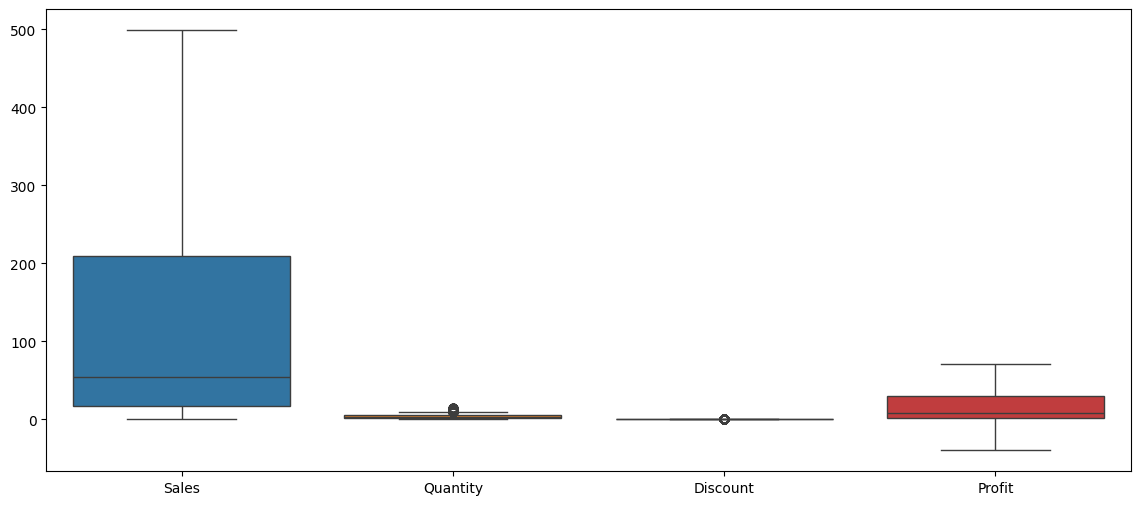

In [58]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df[['Sales','Quantity','Discount','Profit']])
plt.show()

In [59]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,Sales,Quantity,Discount,Profit,Delivery Days,Order Month,Order Year,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,261.960,2,0.00,41.913600,3,11,2016,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,498.930,3,0.00,70.816875,3,11,2016,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,14.620,2,0.00,6.871400,4,6,2016,False,True,False,...,False,False,False,True,False,False,False,False,False,False
3,498.930,5,0.45,-39.724125,7,10,2015,False,False,True,...,False,False,False,False,False,False,False,False,False,True
4,22.368,2,0.20,2.516400,7,10,2015,False,False,True,...,False,False,False,False,False,False,False,True,False,False


In [60]:
X = df_encoded.drop('Profit', axis=1)
y = df_encoded['Profit']

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [62]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px"> Comparing Multiple Models </div>

<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px"> 1. Linear Regression</div>

In [65]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

print("Linear Regression R2:", round(r2_score(y_test, pred_lr) * 100, 2),'%')

Linear Regression R2: 55.73 %


<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px"> 2. K Nearest Neighbour </div>

In [66]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_test_scaled)

print("KNN R2:", round(r2_score(y_test, pred_knn) * 100, 2),'%')

KNN R2: 48.27 %


<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px"> 3. Decision Tree </div>

In [67]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree R2:", round(r2_score(y_test, pred_dt) * 100, 2),'%')

Decision Tree R2: 69.22 %


<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px">4. Random Forest</div>

In [68]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest R2:", round(r2_score(y_test, pred_rf) * 100, 2),'%')

Random Forest R2: 83.31 %


<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px">5. XGBoost Regressor </div>

In [71]:
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("XGBoost R2:", round(r2_score(y_test, pred_xgb) * 100, 2),'%')

XGBoost R2: 81.67 %


<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px"> Hyperparameter Tuning </div>

In [79]:
rf = RandomForestRegressor(random_state=42)

params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.8278101867649861


In [80]:
best_model = grid.best_estimator_

pred_final = best_model.predict(X_test)

print("Final Test R2:", r2_score(y_test, pred_final))
print("MAE:", mean_absolute_error(y_test, pred_final))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_final)))

Final Test R2: 0.834661678874266
MAE: 5.5651326020633425
RMSE: 11.78786139554126


In [81]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("CV Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

CV Scores: [0.81903937 0.81210854 0.84659412 0.85854619 0.83803005]
Average CV Score: 0.834863653608978


<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px"> Cross-Validation Comparison </div>

In [82]:
results = pd.DataFrame({
    'Model': ['Linear', 'KNN', 'Decision Tree', 'Random Forest'],
    'R2 Score': [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_knn),
        r2_score(y_test, pred_dt),
        r2_score(y_test, pred_rf)
    ]
})

results.sort_values(by='R2 Score', ascending=False)

,Model,R2 Score
3,Random Forest,0.833085
2,Decision Tree,0.692167
0,Linear,0.557307
1,KNN,0.482702


<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px"> Save Model </div>

In [83]:
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
    
print('Model saved sucessfully!')

Model saved sucessfully!


<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px"> Save Features </div>

In [84]:
with open('features.pkl', 'wb') as f:
    pickle.dump(X.columns.to_list(), f)

print('Features saved successfully!')

Features saved successfully!


<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-weight: bold; font-size: 20px"> Save Scaler </div>

In [85]:
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Scaler saved successfully!')

Scaler saved successfully!


<div style="border: 2px solid #ffff; border-radius: 5px; padding: 5px; width: auto; font-size: 20px">

<b>Business Recommendations & Conclusion</b>

Based on insights:
- Reduce unnecessary discounts
- Focus more on Technology category
- Improve Furniture margins
- Improve Central region strategy
- Use prediction tool before large discounts

</div>